In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
#import matplotlib.pyplot as plt
#import matplotlib as mpl
import muon as mu
import anndata as ad

%load_ext autoreload
%autoreload 2
%matplotlib inline

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata

In [2]:
# --- Configuration ---
RNA_COUNTS_FILE = "../data/mouse_brain_data/GSM4156610_brain.rna.counts.txt.gz"
ATAC_COUNTS_FILE = "../data/mouse_brain_data/GSM4156599_brain.counts.txt.gz" # Matrix Market sparse file
ATAC_PEAKS_FILE = "../data/mouse_brain_data/GSM4156599_brain.peaks.bed.gz" # Peaks BED file
CELLTYPE_FILE = "../data/mouse_brain_data/GSM4156599_brain_celltype.txt.gz" # Contains paired barcodes and cell types

## scRNA

In [4]:
# Load the cell type/pairing file
# This file links ATAC and RNA barcodes for the paired cells (3293 cells)

df_celltype = pd.read_csv(CELLTYPE_FILE, sep='\t')

In [5]:
df_celltype = df_celltype.set_index('rna.bc')

In [6]:
# Get the list of paired RNA barcodes to use as common cell IDs

common_cell_ids = df_celltype.index.tolist()

In [7]:
# Load RNA counts matrix (Genes x Cells)

df_rna_counts = pd.read_csv(RNA_COUNTS_FILE, sep='\t', index_col=0)

In [8]:
# Clean the column names (cell barcodes) in the RNA counts DataFrame
# They use commas (,) but the celltype file uses periods (.)
# Replace commas with periods to match the common_cell_ids format

df_rna_counts.columns = df_rna_counts.columns.str.replace(',', '.', regex=False)

In [9]:
# Subset the RNA counts DataFrame to keep only the columns (cells) that are in our paired set
# This aligns the RNA data to the 3293 paired cells
# .reindex(columns=...) will select the columns and also handle cases where a barcode might be missing (inserts NaNs)
# We use .dropna(axis=1) to remove any columns that were entirely NaN if reindexing failed
df_rna_subset = df_rna_counts.reindex(columns=common_cell_ids).dropna(axis=1)

In [12]:
# Verify that the columns now exactly match the common cell IDs
if list(df_rna_subset.columns) != common_cell_ids:
     print("Error: Subsetting RNA counts failed to exactly match common cell IDs!")
     # Handle error - critical for alignment
else:
     print("RNA counts columns successfully subsetted and aligned to common cell IDs.")

RNA counts columns successfully subsetted and aligned to common cell IDs.


In [15]:
# Transpose the DataFrame to be Cells x Genes for AnnData
df_rna_transposed = df_rna_subset.T.copy() # Use .T for transpose and .copy()

In [16]:
# Create the AnnData object for RNA
# X: The transposed counts matrix (Paired_Cells x Genes)
# obs: Observation metadata (cells). Index should be the common cell IDs.
# var: Variable metadata (genes). Index should be the gene IDs.
adata_rna = ad.AnnData(
    X=df_rna_transposed,
    obs=pd.DataFrame(index=df_rna_transposed.index), # Use transposed index (common cell IDs) for obs names
    var=pd.DataFrame(index=df_rna_transposed.columns) # Use transposed columns (gene IDs) for var names
)

In [31]:
# Add cell type annotations to adata_rna.obs
# The index of adata_rna.obs is common_cell_ids (rna.bc)
# The index of df_celltype is also rna.bc
# Merge df_celltype (keeping only the 'celltype' column) into adata_rna.obs
adata_rna.obs = adata_rna.obs.merge(df_celltype[['celltype']], left_index=True, right_index=True, how='left')

## QC for RNA

Check for mitochondrial genes

In [43]:
adata_rna.var_names.str.startswith("Mt-").sum()

0

In [44]:
sc.pp.calculate_qc_metrics(
    adata_rna, inplace=True, log1p=True
)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


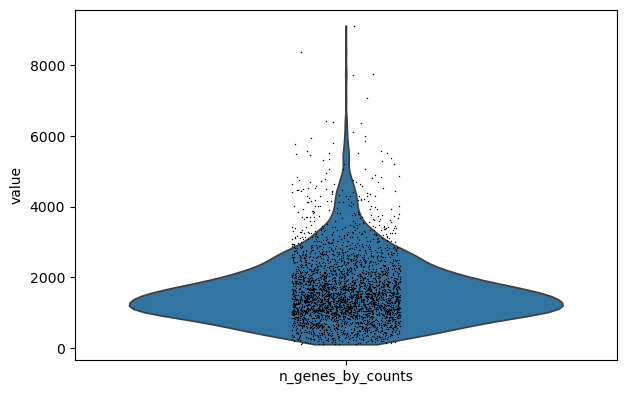

In [56]:
sc.pl.violin(
    adata_rna,
    ["n_genes_by_counts"]
)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


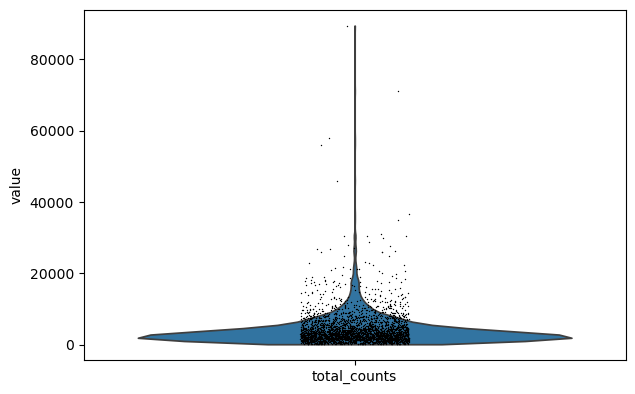

In [53]:
sc.pl.violin(
    adata_rna,
    ["total_counts"]
)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_utils.py:715: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


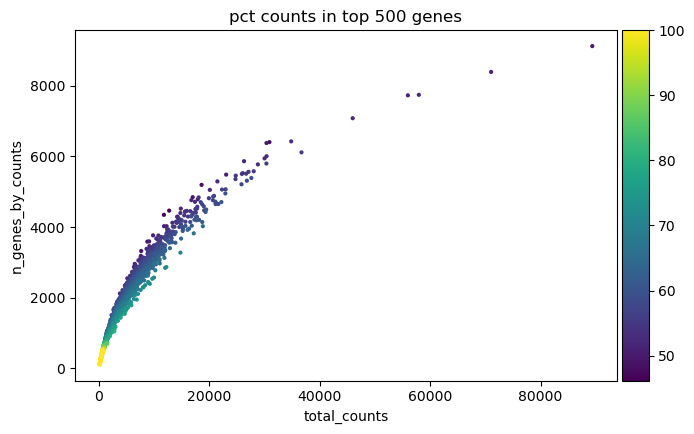

In [61]:
sc.pl.scatter(adata_rna, "total_counts", "n_genes_by_counts", color="pct_counts_in_top_500_genes")

In [92]:
sc.pp.filter_cells(adata_rna, min_genes=100)

In [94]:
sc.pp.filter_genes(adata_rna, min_cells=2)

In [96]:
#sc.pp.scrublet(adata_rna, copy=True)

## Normalization

In [101]:
# Saving count data
adata_rna.layers["counts"] = adata_rna.X.copy()

In [102]:
# Normalizing to median total counts
sc.pp.normalize_total(adata_rna)
# Logarithmize the data
sc.pp.log1p(adata_rna)

## Feature Selection

In [106]:
sc.pp.highly_variable_genes(adata_rna, n_top_genes=2000)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']


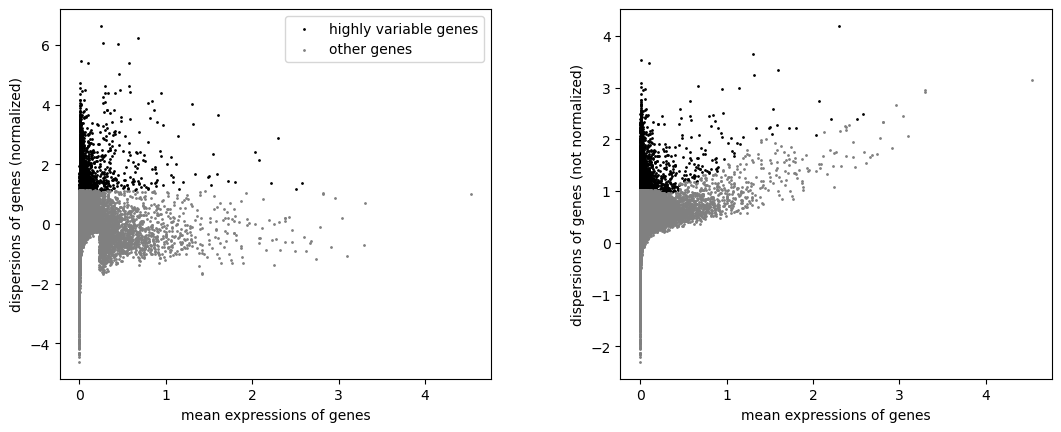

In [109]:
sc.pl.highly_variable_genes(adata_rna)

## Dimensionality Reduction

In [110]:
sc.tl.pca(adata_rna)

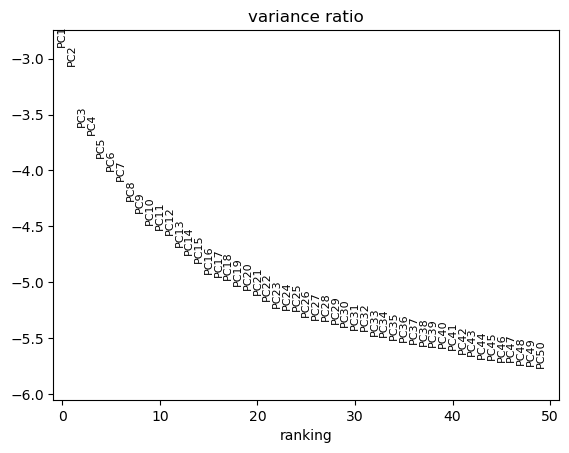

In [111]:
sc.pl.pca_variance_ratio(adata_rna, n_pcs=50, log=True)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


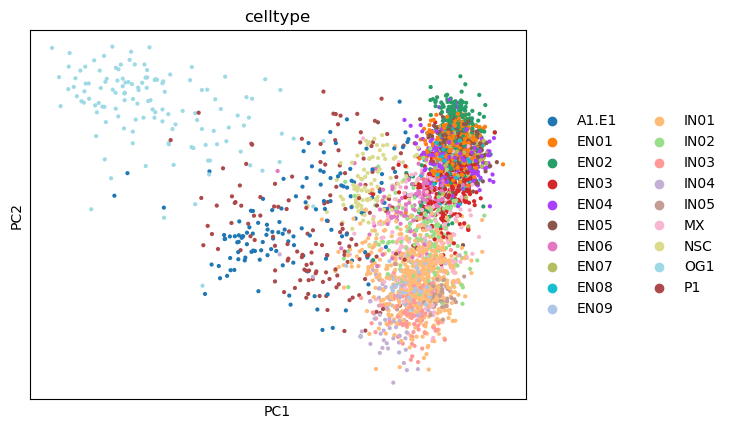

In [116]:
sc.pl.pca(
    adata_rna, color="celltype"
)

In [34]:
adata_sc.obs["rna.bc"] = adata_sc.obs.index.astype(str)

In [35]:
cell_meta["rna.bc"] = cell_meta["rna.bc"].astype(str)

NameError: name 'cell_meta' is not defined

In [ ]:
# Ensure the barcode in adata_sc.obs is a string and normalize the barcode format by replacing commas with periods
adata_sc.obs["rna.bc"] = adata_sc.obs["rna.bc"].astype(str).str.replace(",", ".")

# Ensure the barcode in cell_meta is a string (just in case)
cell_meta["rna.bc"] = cell_meta["rna.bc"].astype(str)

# Merge adata_sc.obs with cell_meta based on the barcode
adata_sc.obs = adata_sc.obs.merge(cell_meta[["rna.bc", "celltype"]], on="rna.bc", how="left")

In [7]:
sc.pp.calculate_qc_metrics(adata_sc, inplace=True, log1p=True)

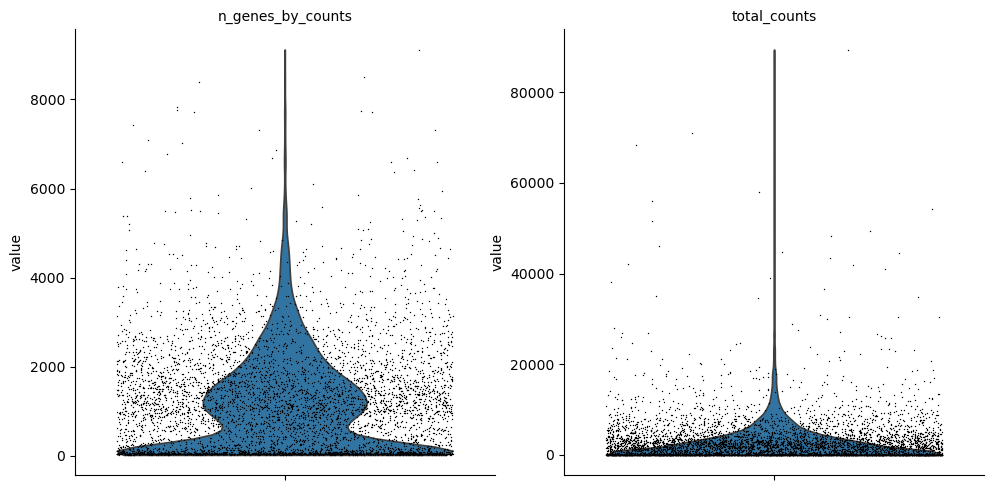

In [8]:
sc.pl.violin(
    adata_sc,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,

)

In [52]:
#sc.pp.filter_cells(adata_sc, min_genes=100)
#sc.pp.filter_genes(adata_sc, min_cells=3)

#sc.pp(adata_sc) scrublet?

In [53]:
# Saving count data
adata_sc.layers["counts"] = adata_sc.X.copy()

In [54]:
sc.pp.normalize_total(adata_sc, target_sum=1e4)  # Normalize to 10,000 reads per cell
sc.pp.log1p(adata_sc)  # Log-transform counts

In [55]:
#sc.pp.highly_variable_genes(adata_sc, n_top_genes=2000)
#sc.pp.highly_variable_genes(adata_sc, min_mean=0.0125, max_mean=3, min_disp=0.5)
#adata_sc = adata_sc[:, adata_sc.var["highly_variable"]]

In [56]:
#sc.pl.highly_variable_genes(adata_sc)

In [57]:
sc.tl.pca(adata_sc, n_comps=50)
#sc.pp.neighbors(adata_sc, n_neighbors=10, n_pcs=40)

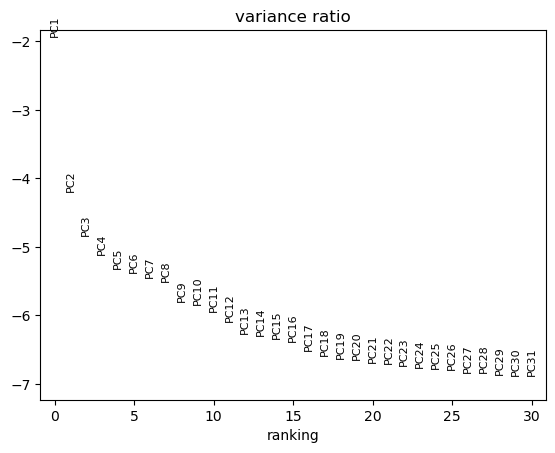

In [58]:
sc.pl.pca_variance_ratio(adata_sc, log=True)
#keep 50

In [59]:
sc.pp.neighbors(adata_sc, n_pcs=50)

In [60]:
sc.tl.umap(adata_sc)

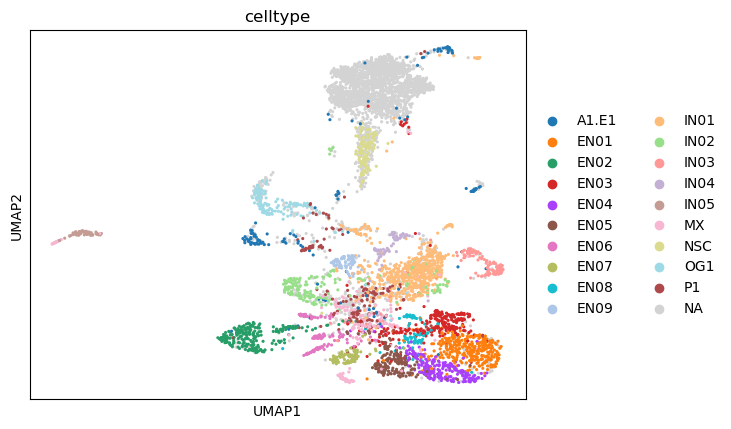

In [61]:
sc.pl.umap(
    adata_sc,
    color="celltype",
)

In [62]:
sc.tl.rank_genes_groups(adata=adata_sc, groupby="celltype", method="t-test")

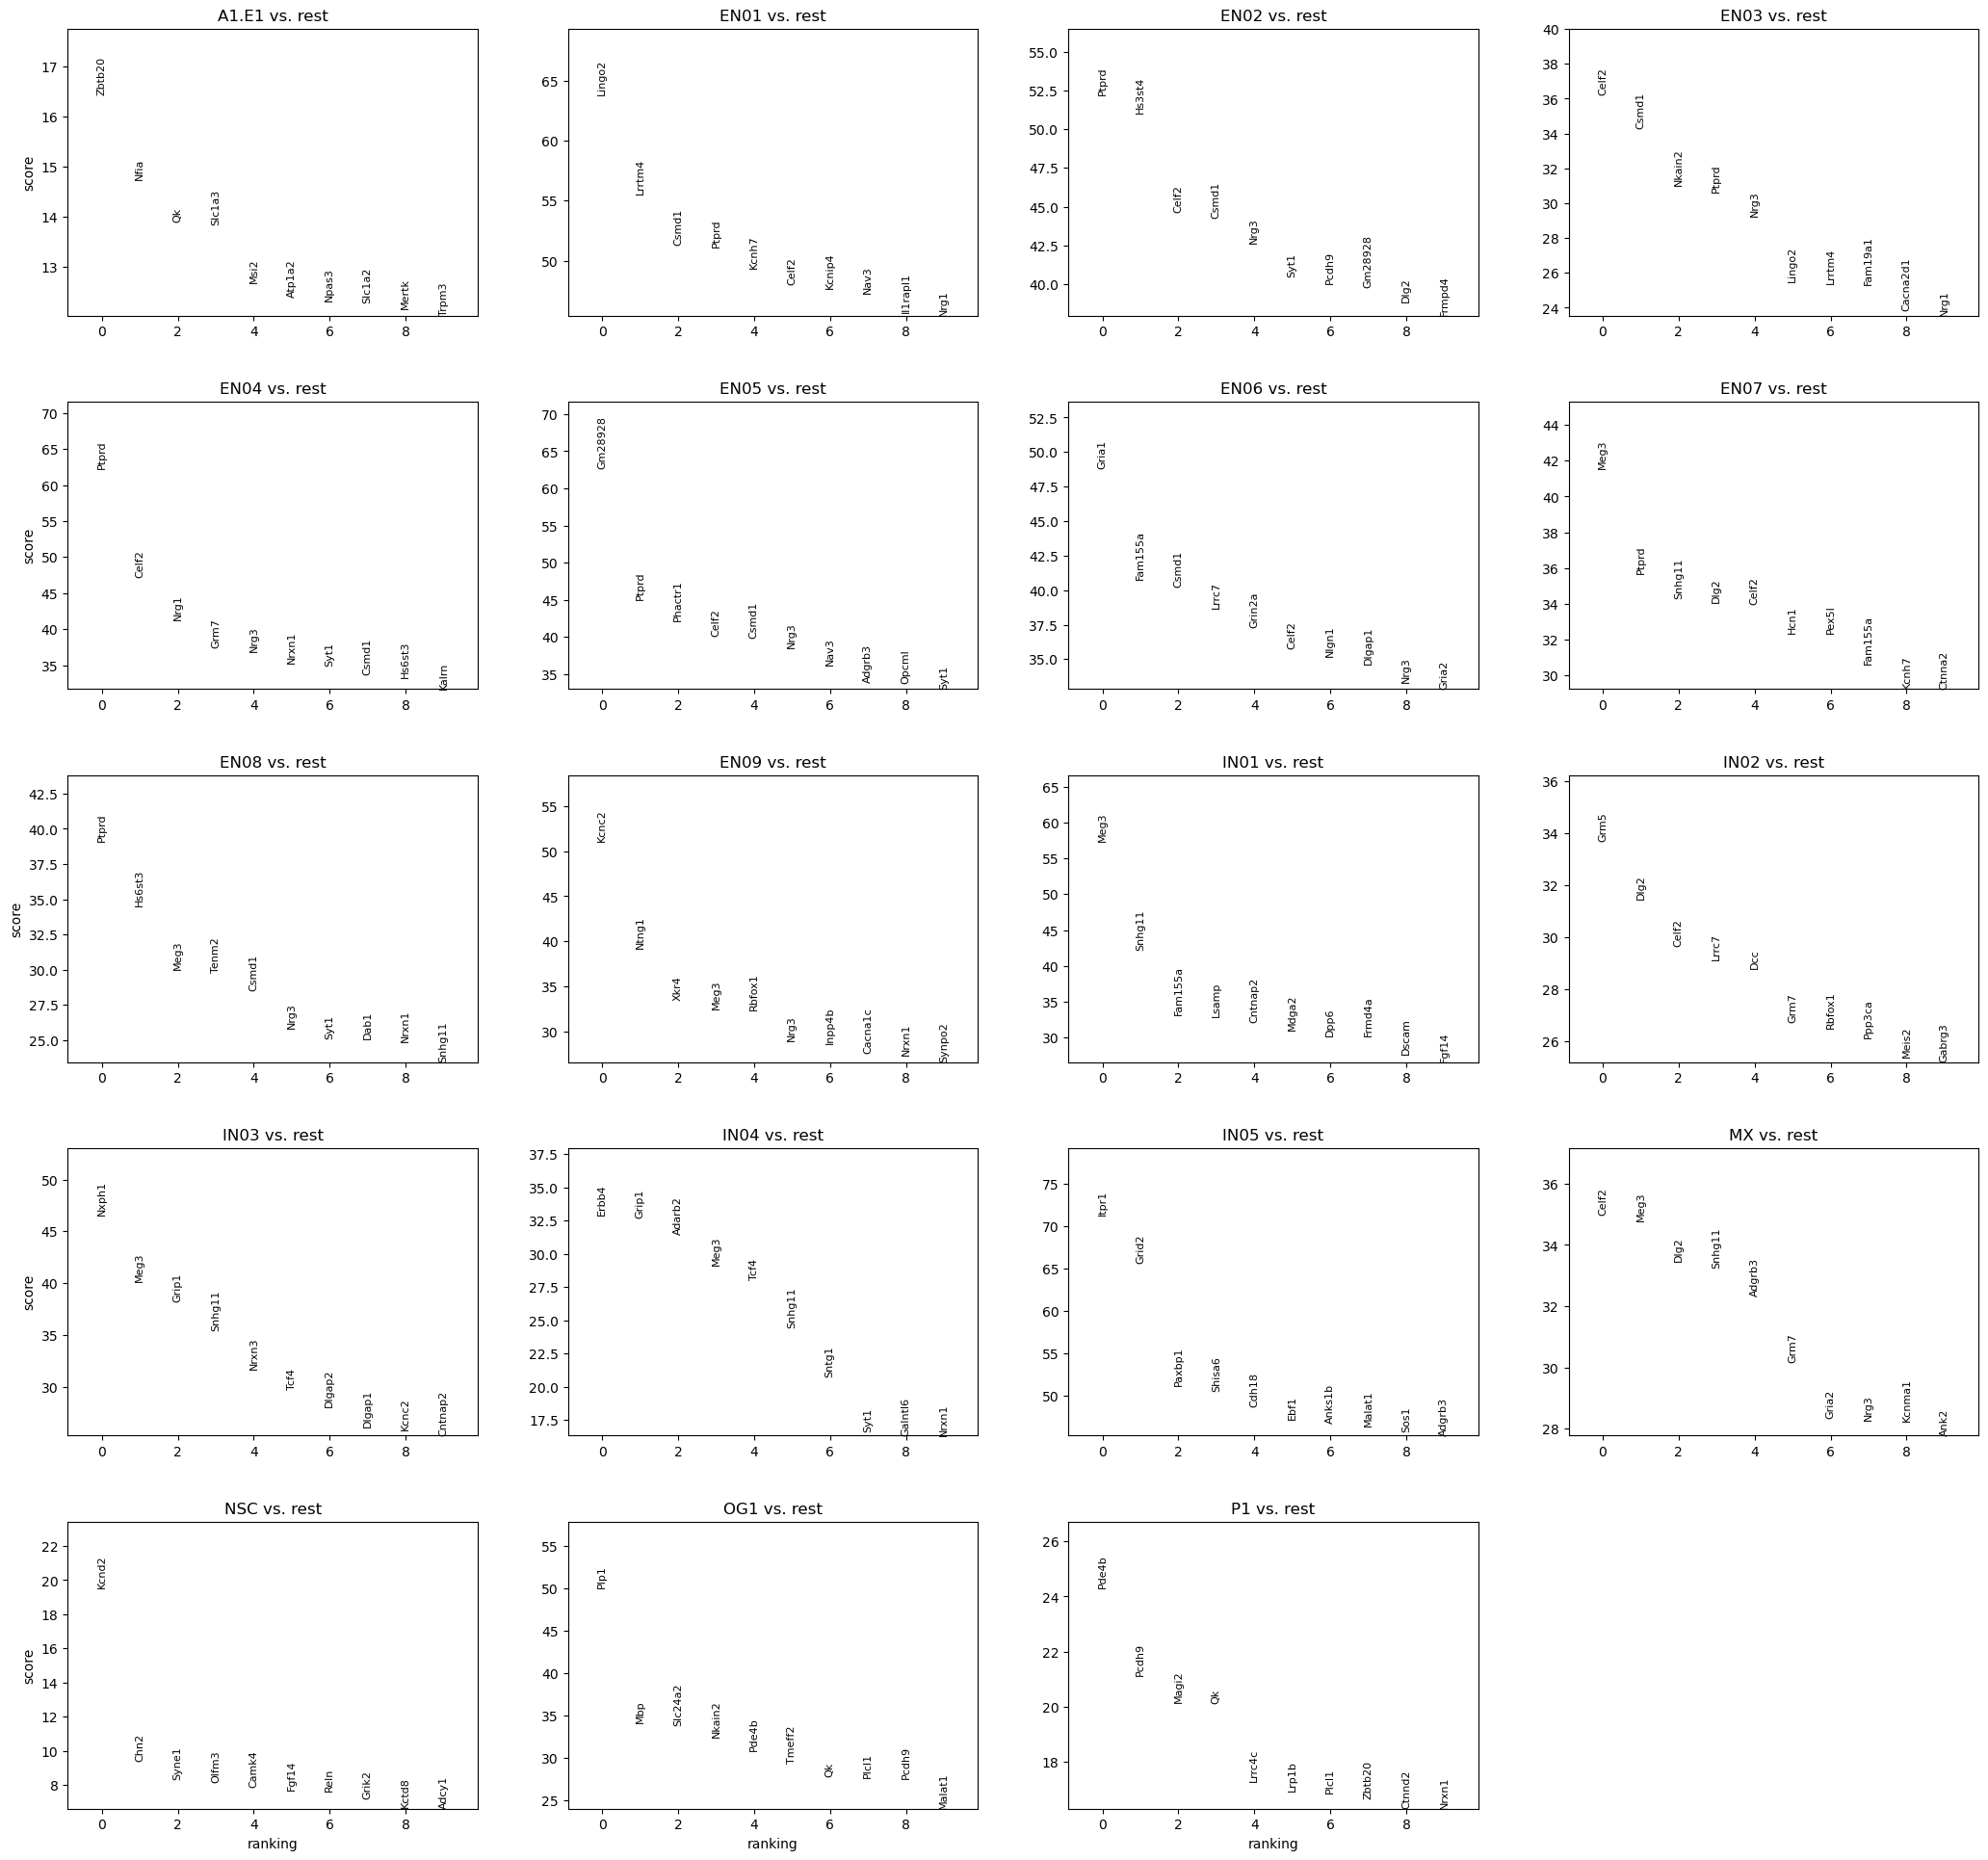

In [63]:
sc.pl.rank_genes_groups(adata_sc, n_genes=10, sharey=False)

In [65]:
marker_genes = sc.get.rank_genes_groups_df(adata_sc, group=None)  # Get all ranked genes

In [66]:
top_marker_genes = marker_genes.groupby("group").head(100)

In [68]:
unique_marker_genes = top_marker_genes["names"].unique()

marker_gene_list = list(unique_marker_genes)

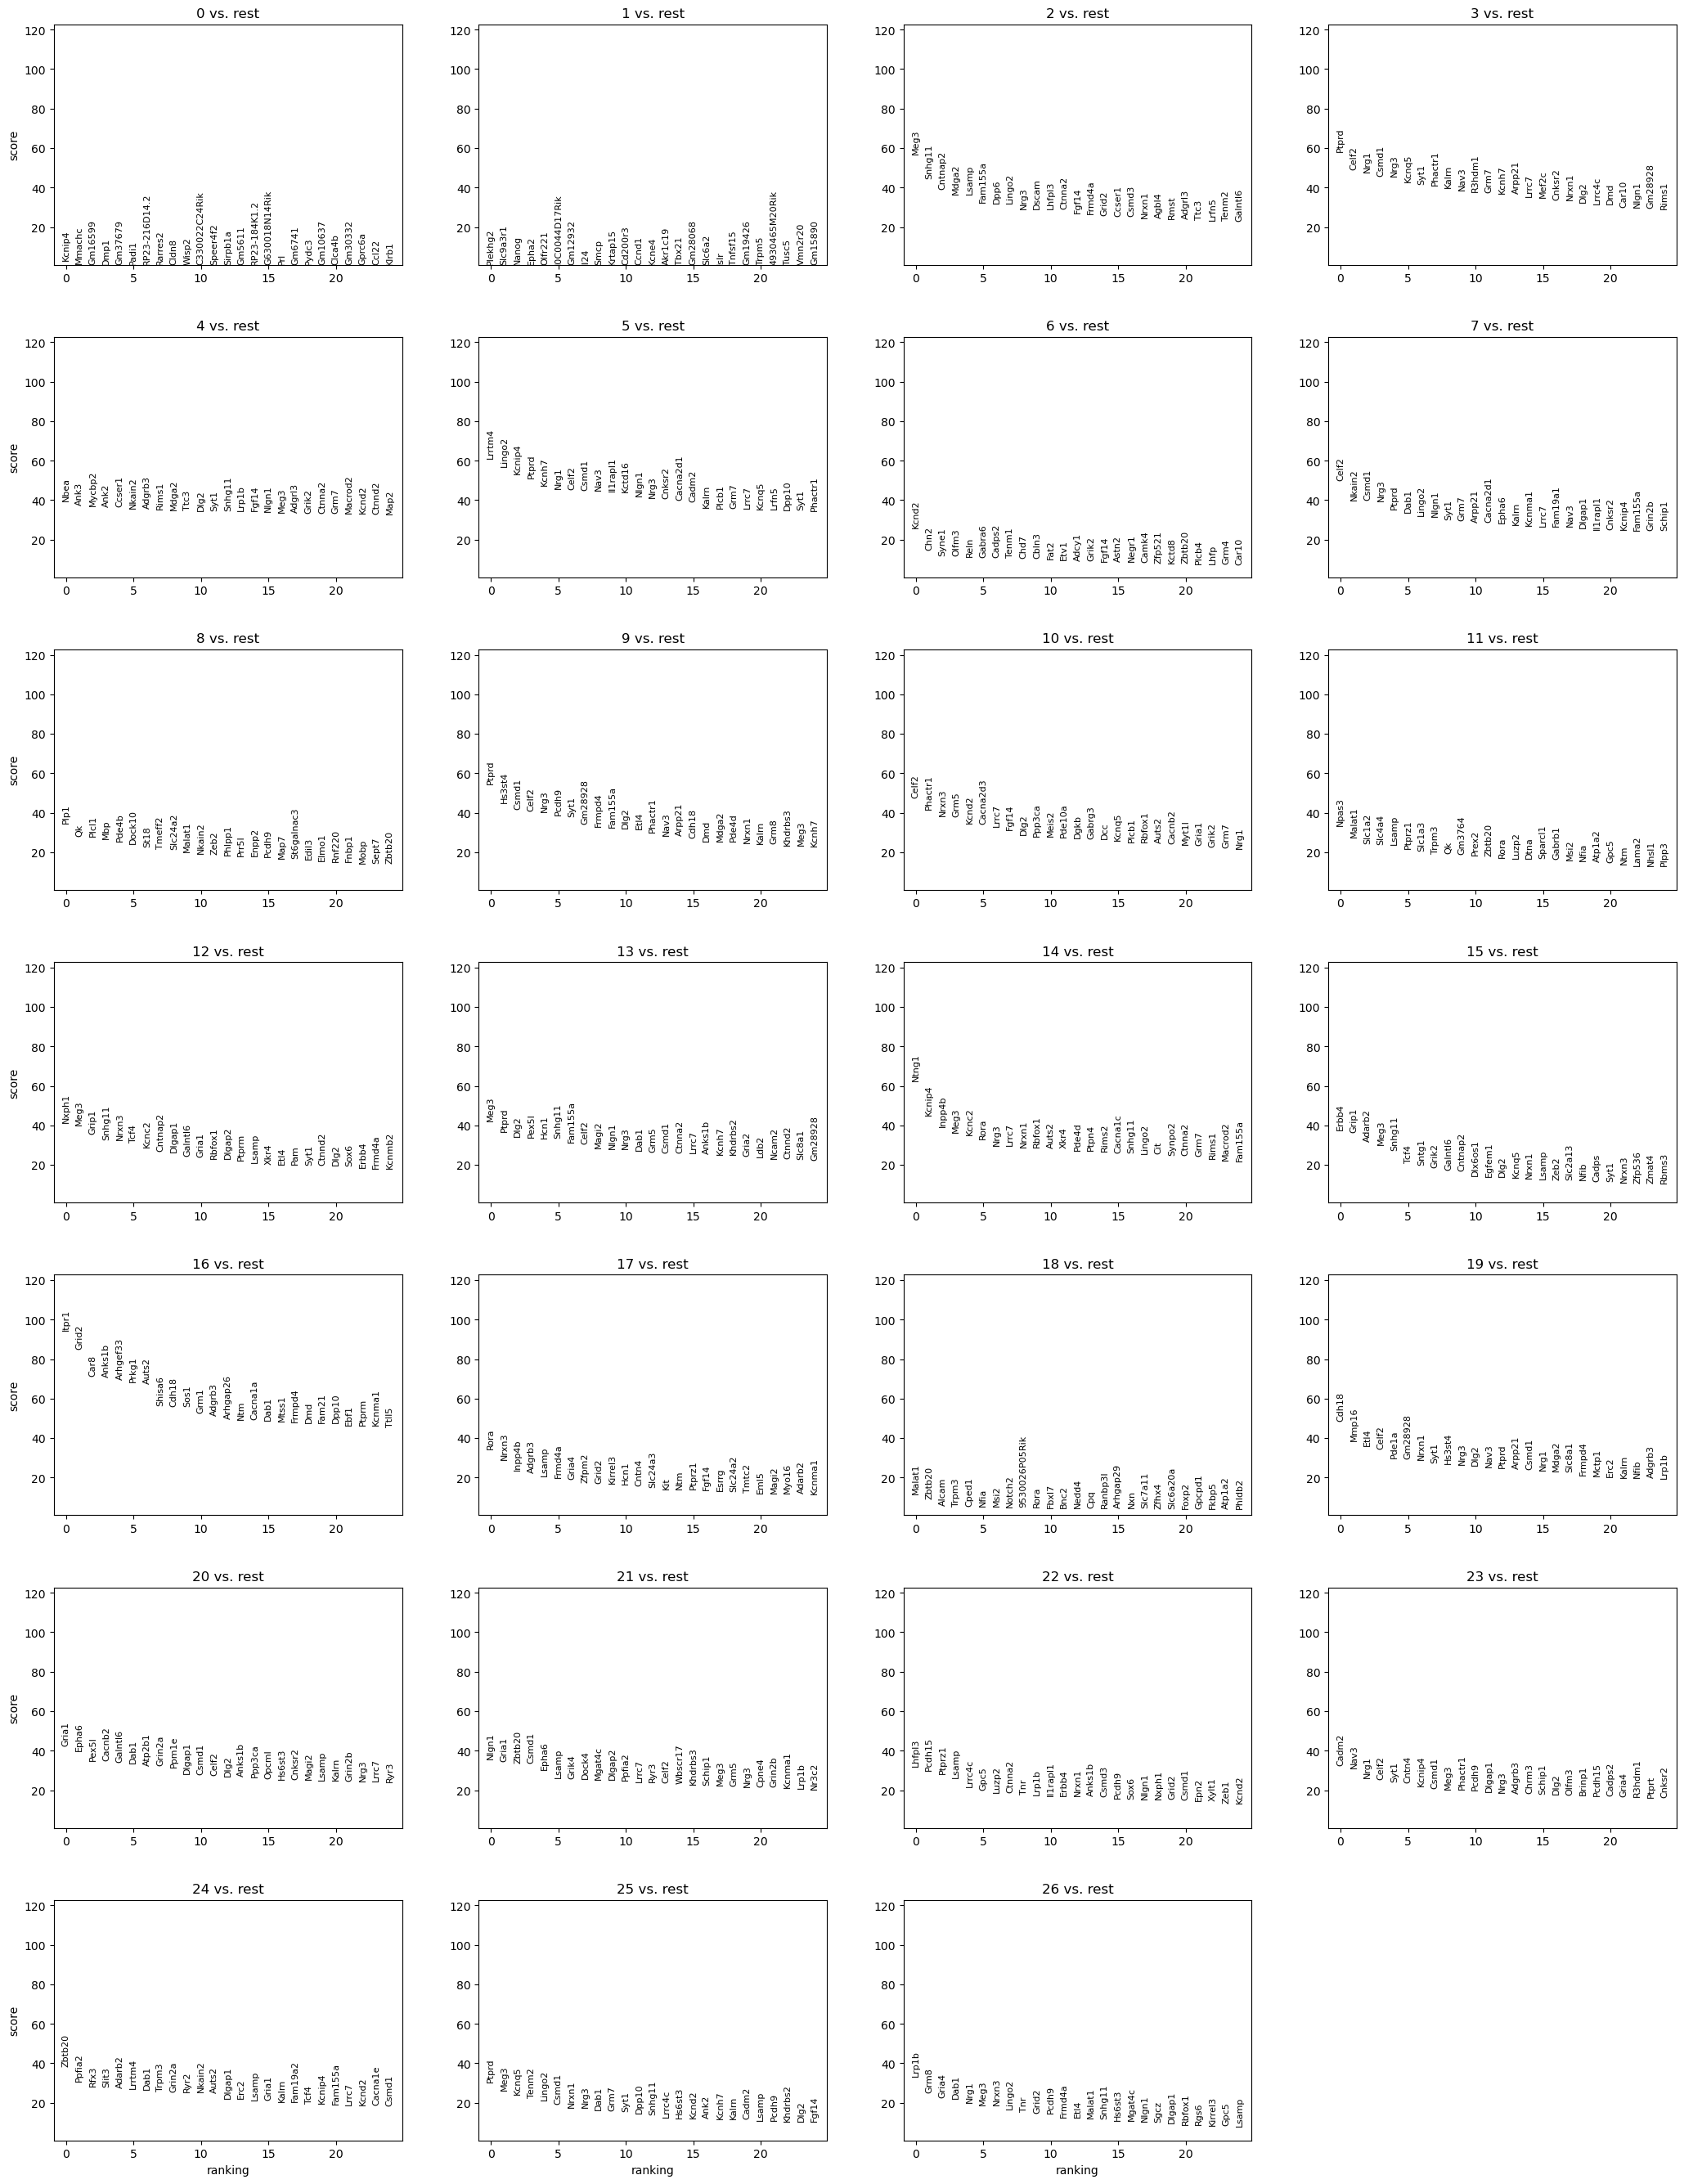

In [53]:
#skip

sc.tl.leiden(
    adata_sc,
    resolution=0.9,
    random_state=0,

    n_iterations=2,
    directed=False,
)

sc.tl.rank_genes_groups(adata_sc, "leiden", method="t-test")

sc.pl.rank_genes_groups(adata_sc, n_genes=25)

In [54]:
sc.tl.leiden(adata_sc, n_iterations=2)

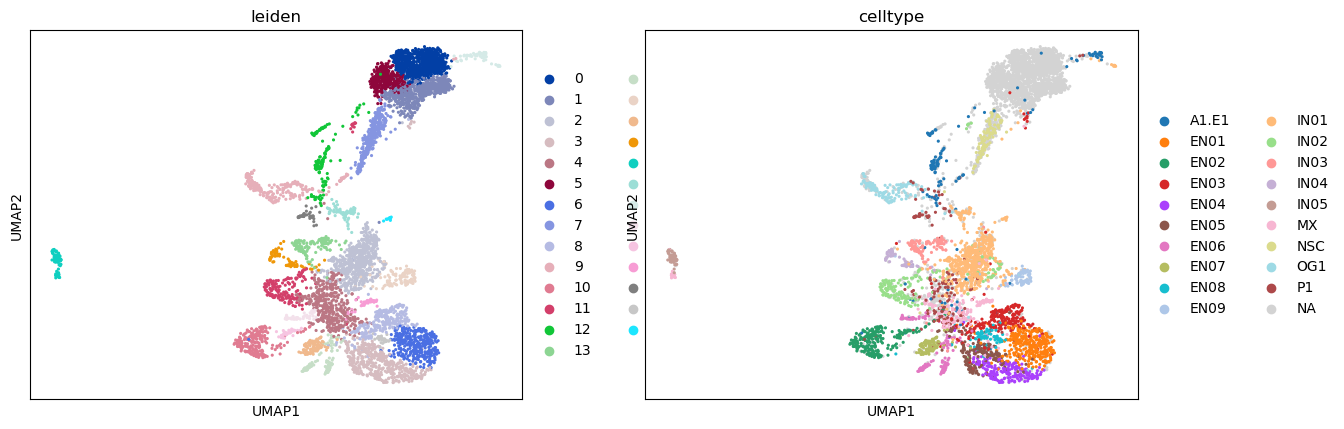

In [55]:
sc.pl.umap(adata_sc, color=["leiden", "celltype"])

In [93]:
#adata_sc.write("h5ad_files/sc.h5ad")

## ATAC

In [1]:
# Load peak-by-cell matrix
#atac_counts = pd.read_csv("data/mouse_brain_data/GSM4156599_brain.counts.txt.gz", sep="\t", index_col=0)
#atac_counts = pd.read_csv("data/mouse_brain_data/GSM4156599_brain.counts.txt.gz", sep="\t")

GSM4156599_brain.atac.fragments.bed.gz	GSM4156599_brain.barcodes.txt.gz  GSM4156599_brain.counts.txt.gz  GSM4156599_brain.peaks.bed.gz  GSM4156599_brain_celltype.txt.gz  GSM4156610_brain.rna.counts.txt.gz

In [11]:
atac = sc.read_mtx("../data/mouse_brain_data/GSM4156599_brain.counts.txt.gz").T

barcodes = pd.read_csv("../data/mouse_brain_data/GSM4156599_brain.barcodes.txt.gz", header=None)

atac.obs["barcode"] = barcodes[0].values

peaks = pd.read_csv("../data/mouse_brain_data/GSM4156599_brain.peaks.bed.gz",
                    sep="\t", header=None, names=["chrom", "start", "end"])

# Create peak ids
peaks["peak_id"] = peaks["chrom"] + ":" + peaks["start"].astype(str) + "-" + peaks["end"].astype(str)

peaks.set_index("peak_id", inplace=True)
atac.var = peaks


rna_barcodes = cell_meta["rna.bc"].tolist()

adata_sc_subset = adata_sc[adata_sc.obs["rna.bc"].isin(rna_barcodes), :]

atac.obs = atac.obs.merge(cell_meta[["rna.bc", "celltype"]], left_on="barcode", right_on="rna.bc")

atac.obs = atac.obs.drop(["rna.bc"],axis=1)

atac.write("atac.h5ad")

In [71]:
adata_sc_subset.write("h5ad_files/subsetted_sc.h5ad")

Hier hatte ich den Verdacht, dass ich eine Zelle hier drüber ausversehen RNA Barcodes dem ATAC ad gegeben hab, das wollte ich hier korrigieren. Ich lese dann auch in ATAC_mapping.ipynb atac_with_correct_barcodes.h5ad anstatt atac.h5ad ein.

In [13]:
# Load ATAC data
atac = sc.read_mtx("data/mouse_brain_data/GSM4156599_brain.counts.txt.gz").T
barcodes = pd.read_csv("data/mouse_brain_data/GSM4156599_brain.barcodes.txt.gz", header=None)
atac.obs["barcode"] = barcodes[0].values

# Load peaks
peaks = pd.read_csv("data/mouse_brain_data/GSM4156599_brain.peaks.bed.gz",
                   sep="\t", header=None, names=["chrom", "start", "end"])
peaks["peak_id"] = peaks["chrom"] + ":" + peaks["start"].astype(str) + "-" + peaks["end"].astype(str)
peaks.set_index("peak_id", inplace=True)
atac.var = peaks

# Check barcode formats
print("ATAC barcodes (first 5):", atac.obs["barcode"].values[:5])
print("Cell meta ATAC barcodes (first 5):", cell_meta["atac.bc"].values[:5])
print("Cell meta RNA barcodes (first 5):", cell_meta["rna.bc"].values[:5])

# The issue is that barcodes in atac.obs["barcode"] are actually RNA barcodes
# Let's check this:
overlap_with_rna = set(atac.obs["barcode"]) & set(cell_meta["rna.bc"])
overlap_with_atac = set(atac.obs["barcode"]) & set(cell_meta["atac.bc"])
print(f"Overlap with RNA barcodes: {len(overlap_with_rna)}")
print(f"Overlap with ATAC barcodes: {len(overlap_with_atac)}")

# Since barcodes.txt.gz contains RNA barcodes, we need to map them to ATAC barcodes
# Create a mapping dictionary from RNA to ATAC
rna_to_atac = dict(zip(cell_meta["rna.bc"], cell_meta["atac.bc"]))

# Add ATAC barcode column based on RNA barcodes
atac.obs["atac_barcode"] = [rna_to_atac.get(bc, "unknown") for bc in atac.obs["barcode"]]

# Format ATAC barcodes for fragments file
import re
formatted_barcodes = []
for bc in atac.obs["atac_barcode"]:
    components = re.findall(r'(R\d+\.\d+|P\d+\.\d+)', bc)
    formatted_bc = ','.join(components)
    formatted_barcodes.append(formatted_bc)

# Add formatted barcodes
atac.obs["formatted_barcode"] = formatted_barcodes

# Set formatted barcodes as observation names
atac.obs_names = atac.obs["formatted_barcode"].values

# Add cell type information directly
atac.obs["celltype"] = atac.obs["barcode"].map(dict(zip(cell_meta["rna.bc"], cell_meta["celltype"])))

# Save the corrected ATAC data
atac.write("h5ad_files/atac_with_correct_barcodes.h5ad")

ATAC barcodes (first 5): ['R1.01.R2.04.R3.55.P1.40' 'R1.01.R2.05.R3.35.P1.40'
 'R1.01.R2.08.R3.45.P1.39' 'R1.01.R2.08.R3.78.P1.39'
 'R1.01.R2.09.R3.52.P1.40']
Cell meta ATAC barcodes (first 5): ['R1.01.R2.04.R3.55.P1.32' 'R1.01.R2.05.R3.35.P1.32'
 'R1.01.R2.08.R3.45.P1.31' 'R1.01.R2.08.R3.78.P1.31'
 'R1.01.R2.09.R3.52.P1.32']
Cell meta RNA barcodes (first 5): ['R1.01.R2.04.R3.55.P1.40' 'R1.01.R2.05.R3.35.P1.40'
 'R1.01.R2.08.R3.45.P1.39' 'R1.01.R2.08.R3.78.P1.39'
 'R1.01.R2.09.R3.52.P1.40']
Overlap with RNA barcodes: 3293
Overlap with ATAC barcodes: 0
